In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import geopandas as gpd
import rasterio
from rasterio.mask import mask

In [2]:
#loading the classified data
target = gpd.read_file("../data/processed/forest_training.gpkg")

In [ ]:
#loading the different spectral bands of the Sentinel-2 data
path_B02 = "../data/raw/satellite/seperate/2018/S2A_MSIL2A_20180919T102021_N0500_R065_T32UPC_20230708T120558.SAFE/GRANULE/L2A_T32UPC_A016936_20180919T102018/IMG_DATA/R10m/T32UPC_20180919T102021_B02_10m.jp2"
path_B03 = "../data/raw/satellite/seperate/2018/S2A_MSIL2A_20180919T102021_N0500_R065_T32UPC_20230708T120558.SAFE/GRANULE/L2A_T32UPC_A016936_20180919T102018/IMG_DATA/R10m/T32UPC_20180919T102021_B03_10m.jp2"
path_B04 = "../data/raw/satellite/seperate/2018/S2A_MSIL2A_20180919T102021_N0500_R065_T32UPC_20230708T120558.SAFE/GRANULE/L2A_T32UPC_A016936_20180919T102018/IMG_DATA/R10m/T32UPC_20180919T102021_B04_10m.jp2"
path_B08 = "../data/raw/satellite/seperate/2018/S2A_MSIL2A_20180919T102021_N0500_R065_T32UPC_20230708T120558.SAFE/GRANULE/L2A_T32UPC_A016936_20180919T102018/IMG_DATA/R10m/T32UPC_20180919T102021_B08_10m.jp2"

def get_image_data(path):

    src = rasterio.open(path)
    data = src.read(1)
    return data, src


In [4]:
#reshaping the data
data_B02, src_B02 = get_image_data(path_B02)
data_B03, src_B03 = get_image_data(path_B03)
data_B04, src_B04 = get_image_data(path_B04)
data_B08, src_B08 = get_image_data(path_B08)

data_B02 = data_B02.reshape(-1,)
data_B03 = data_B03.reshape(-1,)
data_B04 = data_B04.reshape(-1,)
data_B08 = data_B08.reshape(-1,)

In [5]:
#saving the data in a Data Frame
satellite_raw_data = {"B02": data_B02, "B03": data_B03, "B04": data_B04, "B08":data_B08}
satellite_df = pd.DataFrame(satellite_raw_data)
satellite_df

,B02,B03,B04,B08
0,1886,2236,2634,3380
1,1916,2252,2694,3410
2,1912,2210,2668,3386
3,1883,2204,2630,3360
4,1866,2208,2610,3338
...,...,...,...,...
120560395,2316,2338,2224,2304
120560396,1536,1828,1644,3398
120560397,1608,2016,1904,4054
120560398,1882,2178,2320,3326


In [6]:
#checking out some of the classified data and plotting it
polygon = target.geometry.iloc[0]

out_image, out_transform = mask(
    src_B08,
    [polygon],
    crop=True
)

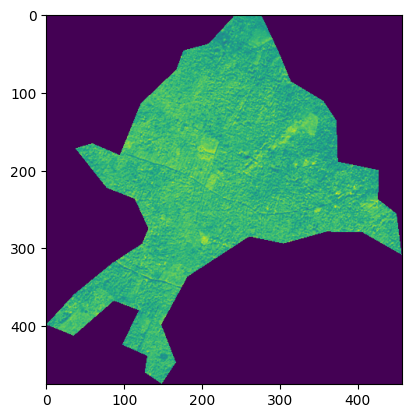

In [7]:
plt.imshow(out_image[0])

In [8]:
#saving all the classified data in a Data Frame for ML
forest_training_df = pd.DataFrame(dtype="Int16")
areas = []

for data, forest_target in zip(target["geometry"], target["class"]):

    single_image_df = pd.DataFrame(dtype="Int16")

    for layer, name in zip([src_B02, src_B03, src_B04, src_B08], ["B02", "B03", "B04", "B08"]):

        out_image, out_transform = mask(
            layer,
            [data],
            crop=True
        )

        single_image_df[name] = out_image.reshape(-1, )

    single_image_df["Forest"] = forest_target
    areas.append(single_image_df)

forest_training_df = pd.concat(areas, ignore_index=True)

forest_training_df[forest_training_df == 0] = np.nan
forest_training_df = forest_training_df.dropna()
forest_training_df["Forest"] = forest_training_df["Forest"].map({"Forest": 1, "Non-Forest":0})


In [9]:
forest_training_df

,B02,B03,B04,B08,Forest
272,1318.0,1463.0,1364.0,3376.0,1
273,1319.0,1430.0,1353.0,3416.0,1
274,1314.0,1412.0,1369.0,3310.0,1
275,1354.0,1475.0,1398.0,3448.0,1
699,1384.0,1395.0,1366.0,3066.0,1
...,...,...,...,...,...
1750268,1843.0,2008.0,2268.0,2760.0,0
1750269,1817.0,1980.0,2262.0,2760.0,0
1750270,1830.0,2060.0,2340.0,2860.0,0
1750271,1893.0,2082.0,2368.0,2932.0,0


In [22]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

In [11]:
#splitting the data in train- and testdata and defining a cross-validation-strategy
X = forest_training_df.drop(columns=["Forest"])
y = forest_training_df["Forest"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, shuffle=True)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

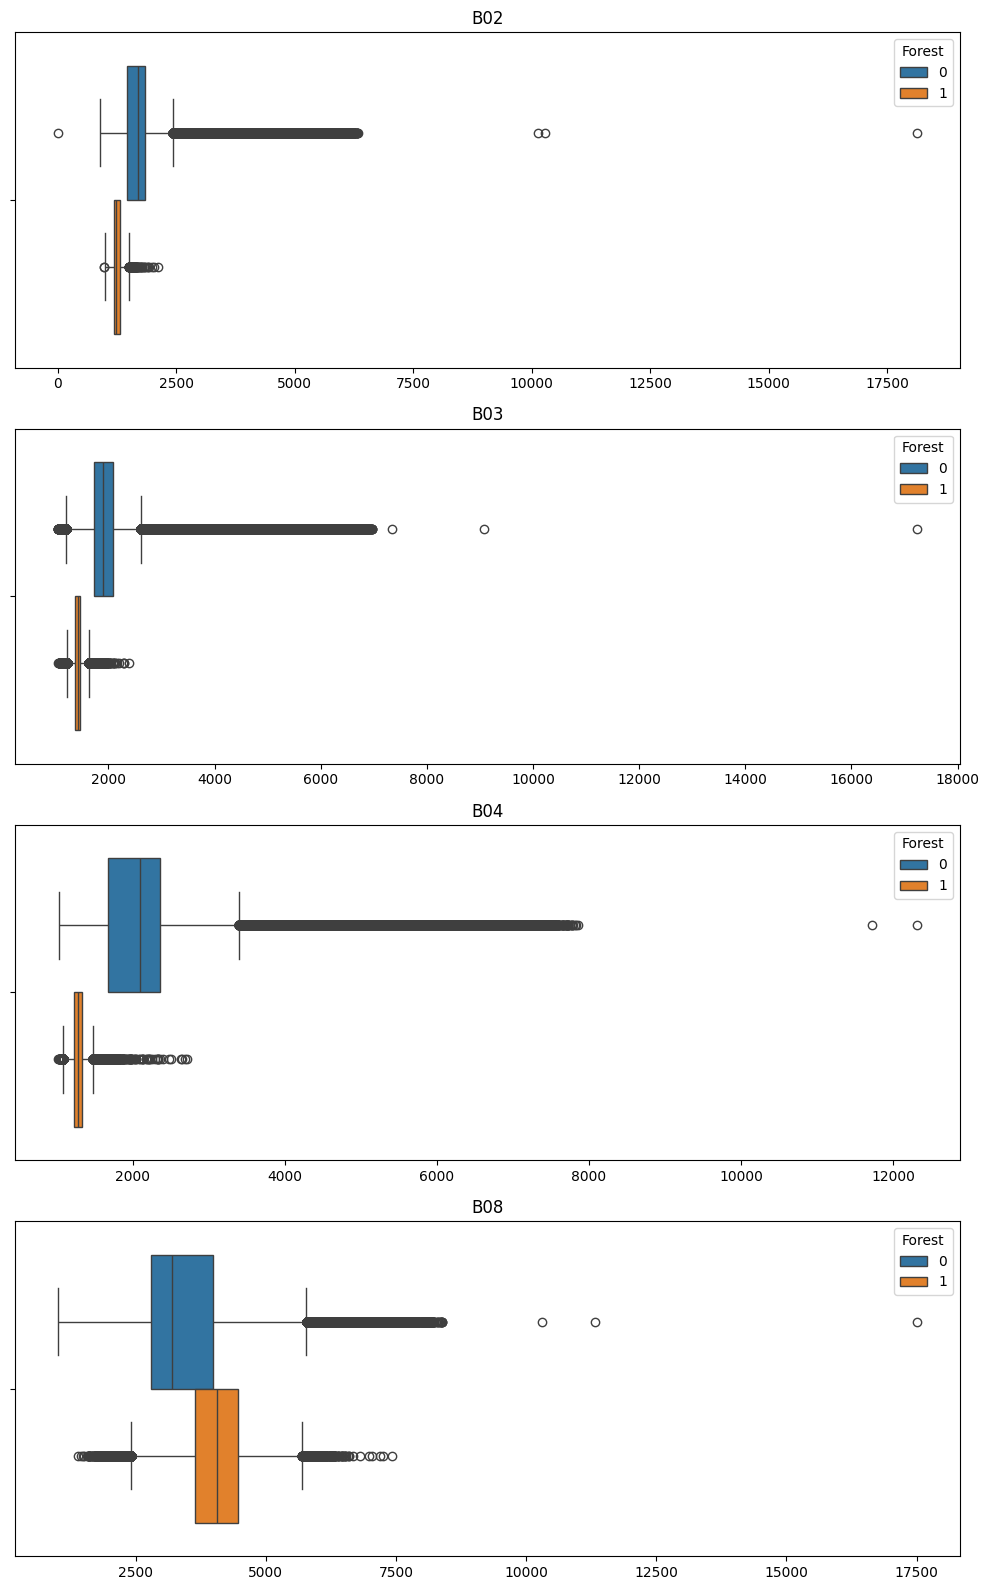

In [12]:
#some plotting
fig, axes = plt.subplots(4, 1, figsize=(10, 16))

for colname, ax in zip(X.columns, axes.ravel()):
    sns.boxplot(X, x=colname, ax=ax, hue=y)
    ax.set_title(colname)
    ax.set_xlabel("")
    
plt.tight_layout()

<Axes: >

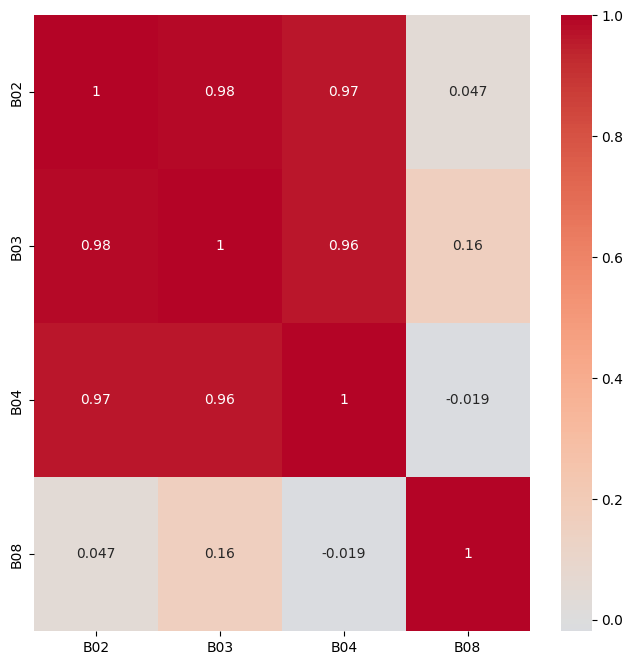

In [13]:
#some more plotting
fig, ax = plt.subplots(figsize = (8, 8))

cont_corr_matrix = X.corr()
sns.heatmap(cont_corr_matrix, annot=True, cmap="coolwarm", center=0)

<Axes: >

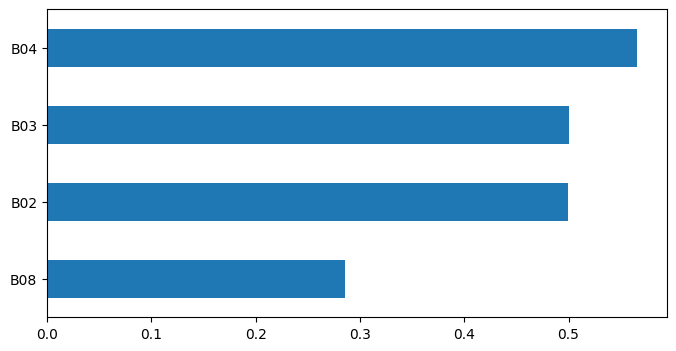

In [14]:
#even some more plotting
fig, ax = plt.subplots(figsize = (8, 4))

cont_target_corr_matrix = X.corrwith(y).abs()
cont_target_corr_matrix.sort_values().plot(kind="barh")

In [ ]:
#evaluating different hyperparameters, but the scikit-learn standard settings are actually pretty good so we keep them
param_grid = {
    "n_estimators": [1, 5, 10, 50, 100],
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [None, 5, 50],
    "max_features": ["sqrt", "log2", None],
}

grid_search_cv = GridSearchCV(
    RandomForestClassifier(random_state=1),
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid_search_cv.fit(X_train, y_train)

print("best parameters:", grid_search_cv.best_params_)
print("best cv-score:", grid_search_cv.best_score_)

results = pd.DataFrame(grid_search_cv.cv_results_)
results

In [ ]:
#evaluating the test data via cross validation
clf_forest = RandomForestClassifier(n_jobs=-1, random_state=1)

scores = cross_val_score(clf_forest, X_train, y_train, cv=cv, scoring="accuracy")

scores.mean()

np.float64(0.981409933019256)

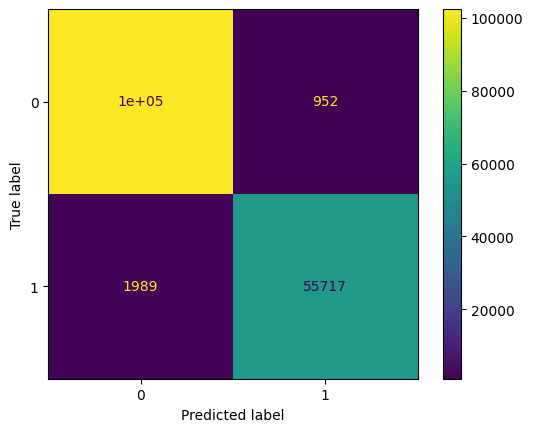

In [19]:
clf_forest.fit(X_train, y_train)
forest_predictions = clf_forest.predict(X_test)

cm = confusion_matrix(
    y_test,
    forest_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

In [ ]:
param_distributions = {
    "n_neighbors": [3, 7, 13, 21, 45, 301],
    "weights": ["uniform", "distance"],
    "metric": ["minkowski", "manhattan", "euclidean", "chebyshev"]
}

randomized_search = RandomizedSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions=param_distributions,
    n_iter=20,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2,
    random_state=0
)

randomized_search.fit(X_train, y_train)

print("Beste Parameter:", randomized_search.best_params_)
print("Bester CV-Score:", randomized_search.best_score_)

results_df = pd.DataFrame(randomized_search.cv_results_)
results_df

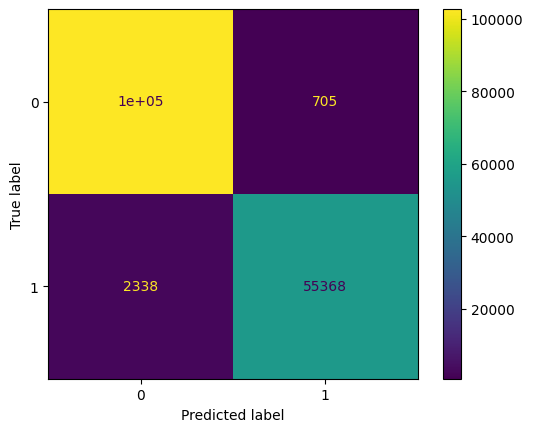

In [20]:
clf_knn = KNeighborsClassifier(n_neighbors=21, weights="distance", metric="minkowski")

clf_knn.fit(X_train, y_train)
knn_predictions = clf_knn.predict(X_test)

cm = confusion_matrix(
    y_test,
    knn_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

In [ ]:
#training the entire model
clf_forest.fit(X, y)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total 

In [ ]:
#classifying the data by splitting it into chunks
chunk_size = 100000

final_forest_df = pd.DataFrame(dtype="Int16")
chunks = []

for start in range(0, len(satellite_df), chunk_size):

    print(start)

    end = start + chunk_size

    chunk_df = satellite_df.iloc[start:end]
    predictions = clf_forest.predict(chunk_df)
    chunk_df["forest_prediction"] = predictions

    chunks.append(chunk_df)

final_forest_df = pd.concat(chunks, ignore_index=True)



In [ ]:
final_forest_df["forest_prediction"].value_counts()

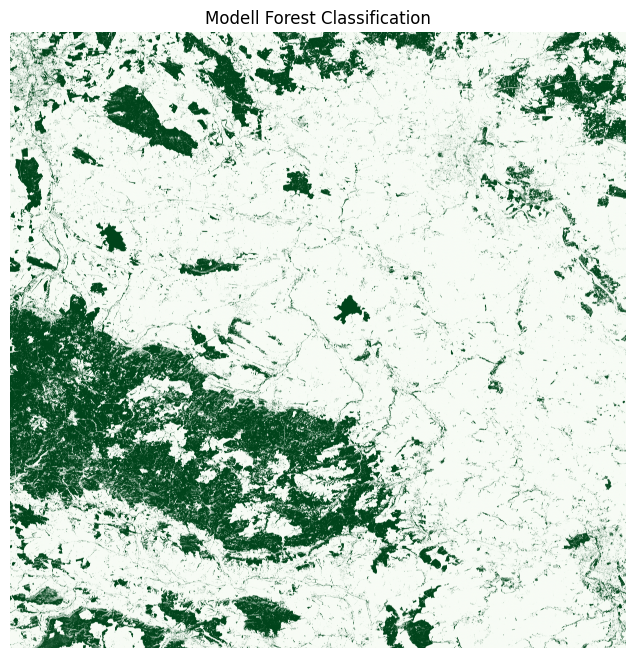

In [ ]:
#plotting the results looks really promising
fig, ax = plt.subplots(figsize = (8, 8))

predictions_2d = np.array(final_forest_df["forest_prediction"]).reshape(10980, 10980)

plt.title("Model Forest Classification")
plt.axis("off")
plt.imshow(predictions_2d, cmap="Greens")

In [36]:
with rasterio.open(
    "../data/processed/forest_classification_2018_forest.tif",
    "w",
    driver="GTiff",
    height=predictions_2d.shape[0],
    width=predictions_2d.shape[1],
    count=1,
    dtype=predictions_2d.dtype,
    crs=src_B04.crs,
    transform=src_B04.transform
) as dst:

    dst.write(predictions_2d, 1)